In [1]:
import numpy as np
import tensorflow as tf
from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 5 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# EN: Choose TensorFlow augmentation by method_id (0~4).
# CN: 根据 method_id 选择 TensorFlow 增强策略（0~4），二分法之外你这里是“5种方案对比”
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    Method 0: No augmentation (Identity).
    Method 1: Rotation.
    Method 2: Translation.
    Method 3: Zoom.
    Method 4: Rotation + Translation + Zoom (+ Contrast for RGB).
    """
    if method_id == 0:
        # EN: No augmentation.
        # CN: 不增强，返回一个恒等映射层
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")

# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（便于判断过拟合）
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build tf.data pipeline.
    # CN: 用 tf.data 加速，并确保“只在训练集做增强”
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # EN: Apply augmentation only for training.
    # CN: 仅训练集增强；验证集不做增强（评估公平）
    def train_map(x, y):
        x = aug(x, training=True)
        return x, y

    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    model = build_cnn(input_shape, num_classes)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc

# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证的 accuracy 与 loss 曲线
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

##  Fashion-MNIST


Fashion-MNIST - Method 0

Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.8257 - loss: 0.4864 - val_accuracy: 0.8741 - val_loss: 0.3490
Epoch 2/10
875/875 - 4s - 4ms/step - accuracy: 0.8816 - loss: 0.3251 - val_accuracy: 0.8919 - val_loss: 0.2963
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.8984 - loss: 0.2787 - val_accuracy: 0.8947 - val_loss: 0.2899
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9094 - loss: 0.2465 - val_accuracy: 0.9061 - val_loss: 0.2565
Epoch 5/10
875/875 - 4s - 4ms/step - accuracy: 0.9165 - loss: 0.2222 - val_accuracy: 0.9039 - val_loss: 0.2630
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9261 - loss: 0.2005 - val_accuracy: 0.9074 - val_loss: 0.2504
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9327 - loss: 0.1807 - val_accuracy: 0.9141 - val_loss: 0.2412
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9400 - loss: 0.1614 - val_accuracy: 0.9164 - val_loss: 0.2296
Epoch 9/10
875/875 - 4s - 4ms/step - accuracy: 0.9465 - loss: 0.1439 - val_accuracy: 

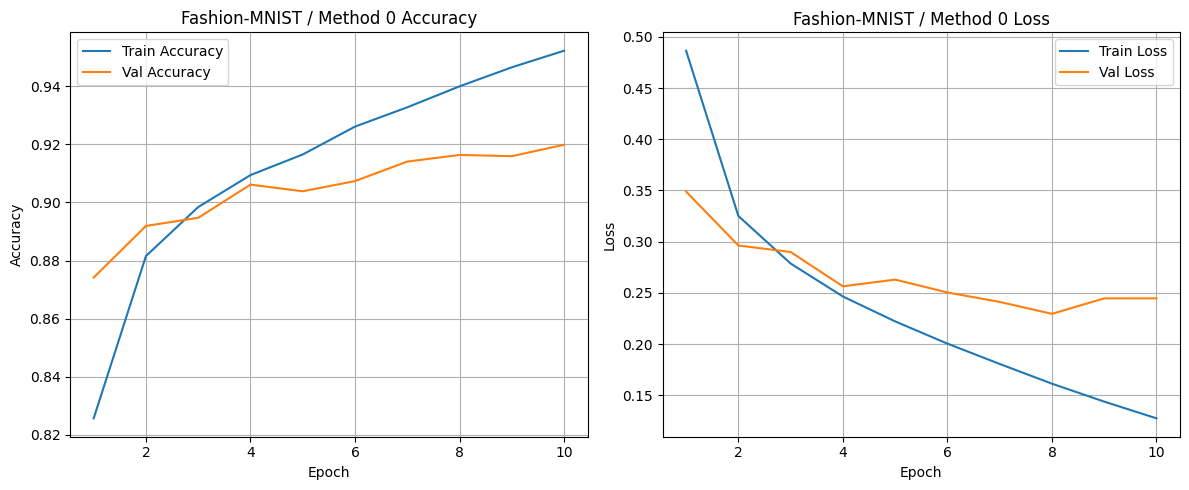


Fashion-MNIST - Method 1
Epoch 1/10
875/875 - 5s - 5ms/step - accuracy: 0.7754 - loss: 0.6196 - val_accuracy: 0.8391 - val_loss: 0.4434
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.8415 - loss: 0.4355 - val_accuracy: 0.8571 - val_loss: 0.3962
Epoch 3/10
875/875 - 4s - 4ms/step - accuracy: 0.8610 - loss: 0.3809 - val_accuracy: 0.8704 - val_loss: 0.3645
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.8726 - loss: 0.3489 - val_accuracy: 0.8866 - val_loss: 0.3222
Epoch 5/10
875/875 - 4s - 4ms/step - accuracy: 0.8812 - loss: 0.3230 - val_accuracy: 0.8870 - val_loss: 0.3137
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.8882 - loss: 0.3051 - val_accuracy: 0.8923 - val_loss: 0.2992
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.8949 - loss: 0.2877 - val_accuracy: 0.8898 - val_loss: 0.3067
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.8969 - loss: 0.2773 - val_accuracy: 0.8971 - val_loss: 0.2871
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9038 - loss: 0.2643 - val_accuracy: 0

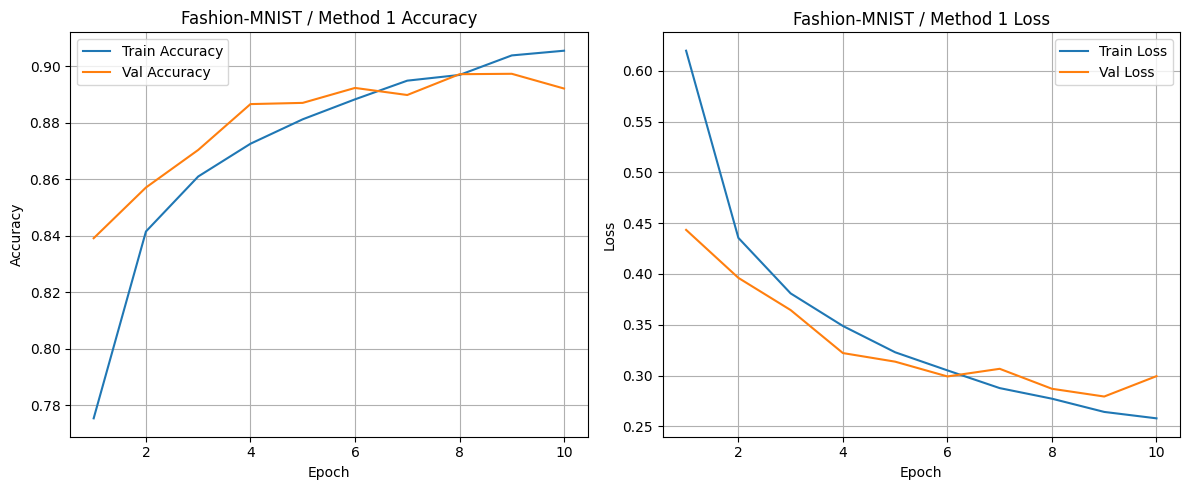


Fashion-MNIST - Method 2
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.7702 - loss: 0.6245 - val_accuracy: 0.8476 - val_loss: 0.4163
Epoch 2/10
875/875 - 4s - 4ms/step - accuracy: 0.8376 - loss: 0.4390 - val_accuracy: 0.8719 - val_loss: 0.3479
Epoch 3/10
875/875 - 4s - 4ms/step - accuracy: 0.8573 - loss: 0.3847 - val_accuracy: 0.8767 - val_loss: 0.3368
Epoch 4/10
875/875 - 4s - 4ms/step - accuracy: 0.8688 - loss: 0.3526 - val_accuracy: 0.8834 - val_loss: 0.3165
Epoch 5/10
875/875 - 4s - 4ms/step - accuracy: 0.8780 - loss: 0.3264 - val_accuracy: 0.8859 - val_loss: 0.3106
Epoch 6/10
875/875 - 4s - 4ms/step - accuracy: 0.8823 - loss: 0.3128 - val_accuracy: 0.8869 - val_loss: 0.2984
Epoch 7/10
875/875 - 4s - 4ms/step - accuracy: 0.8888 - loss: 0.2957 - val_accuracy: 0.8983 - val_loss: 0.2740
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.8928 - loss: 0.2857 - val_accuracy: 0.9034 - val_loss: 0.2587
Epoch 9/10
875/875 - 4s - 4ms/step - accuracy: 0.8990 - loss: 0.2712 - val_accuracy: 0

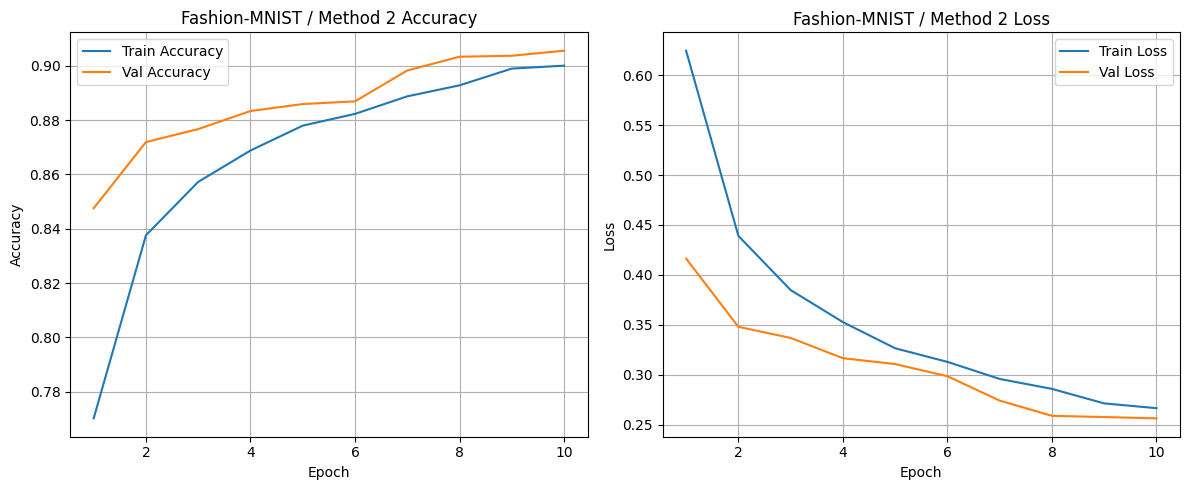


Fashion-MNIST - Method 3
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.8025 - loss: 0.5449 - val_accuracy: 0.8694 - val_loss: 0.3679
Epoch 2/10
875/875 - 4s - 4ms/step - accuracy: 0.8661 - loss: 0.3733 - val_accuracy: 0.8796 - val_loss: 0.3344
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.8801 - loss: 0.3279 - val_accuracy: 0.8863 - val_loss: 0.3181
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.8932 - loss: 0.2925 - val_accuracy: 0.8978 - val_loss: 0.2838
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9009 - loss: 0.2706 - val_accuracy: 0.8922 - val_loss: 0.3022
Epoch 6/10
875/875 - 5s - 5ms/step - accuracy: 0.9075 - loss: 0.2517 - val_accuracy: 0.9009 - val_loss: 0.2713
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9143 - loss: 0.2331 - val_accuracy: 0.9074 - val_loss: 0.2506
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9188 - loss: 0.2195 - val_accuracy: 0.9078 - val_loss: 0.2469
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9250 - loss: 0.2044 - val_accuracy: 0

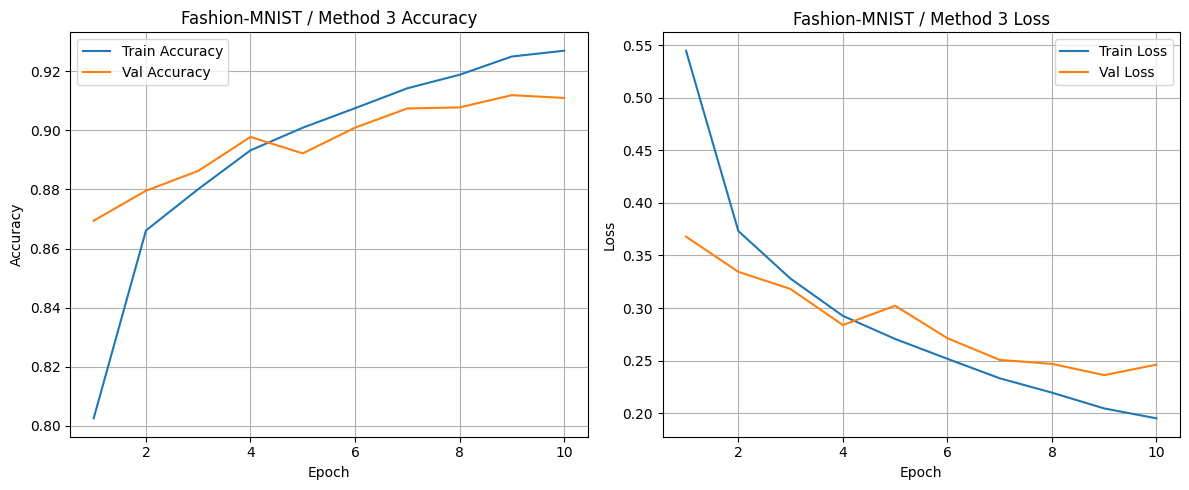


Fashion-MNIST - Method 4
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.7196 - loss: 0.7545 - val_accuracy: 0.7811 - val_loss: 0.5925
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.7890 - loss: 0.5641 - val_accuracy: 0.7884 - val_loss: 0.5758
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.8141 - loss: 0.5034 - val_accuracy: 0.8238 - val_loss: 0.4815
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.8281 - loss: 0.4620 - val_accuracy: 0.8550 - val_loss: 0.4072
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.8364 - loss: 0.4372 - val_accuracy: 0.8421 - val_loss: 0.4376
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.8459 - loss: 0.4154 - val_accuracy: 0.8475 - val_loss: 0.4255
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.8544 - loss: 0.3940 - val_accuracy: 0.8619 - val_loss: 0.3753
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.8564 - loss: 0.3844 - val_accuracy: 0.8686 - val_loss: 0.3564
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.8622 - loss: 0.3671 - val_accuracy: 0

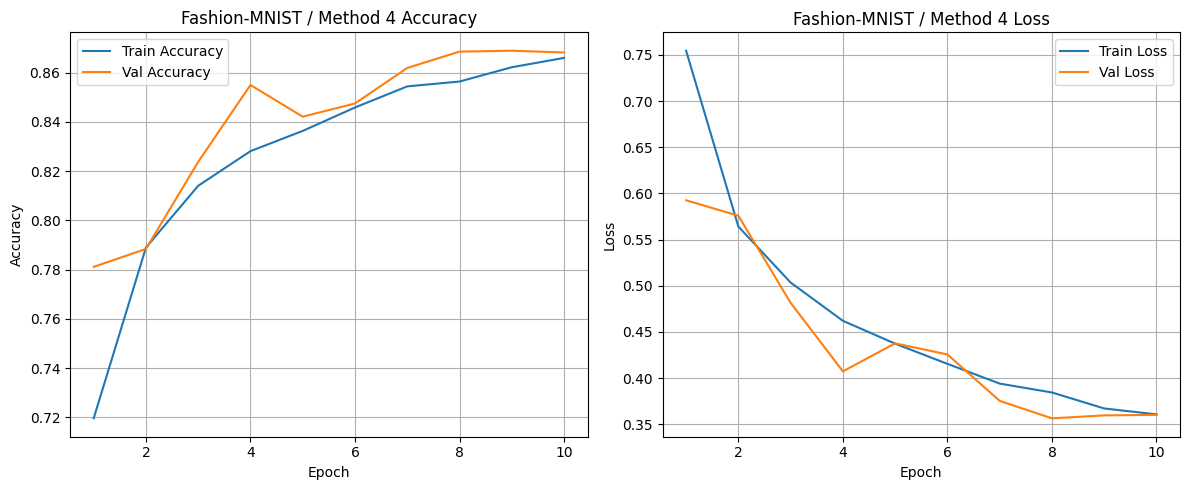


Final accuracy summary (Fashion-MNIST):
Method 0: train_acc=0.9522, val_acc=0.9199
Method 1: train_acc=0.9054, val_acc=0.8921
Method 2: train_acc=0.9001, val_acc=0.9056
Method 3: train_acc=0.9270, val_acc=0.9110
Method 4: train_acc=0.8660, val_acc=0.8682


In [3]:
from keras.datasets import fashion_mnist

# EN: Load Fashion-MNIST and merge.
# CN: 加载 Fashion-MNIST 并合并
(X0, y0), (X1, y1) = fashion_mnist.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# EN: Cleaning = MinMaxScaling to [0,1].
# CN: 清洗=MinMaxScaling 到 [0,1]
X = X.astype("float32")
X = (X - X.min()) / (X.max() - X.min() + 1e-8)

# EN: Add channel dim.
# CN: 增加通道维度
X = X[..., None]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (28, 28, 1)
num_classes = 10
is_rgb = False

results = {}

for method_id in range(5):
    print("\n==============================")
    print(f"Fashion-MNIST - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"Fashion-MNIST / Method {method_id}")

print("\nFinal accuracy summary (Fashion-MNIST):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

## Conclusion for Fashion-MNIST (TensorFlow Data Augmentation)